# 01 — Exploratory Data Analysis: Default Patterns

**Dataset:** Home Credit Default Risk (Kaggle)  
**Goal:** Understand the distribution of defaults, feature correlations,
and the patterns that differentiate defaulters from non-defaulters.

## Contents
1. Data loading & schema overview
2. Target variable distribution (class imbalance)
3. Demographic analysis (age, gender, income)
4. Credit utilisation, loan ratios & employment anomaly
5. Categorical feature default rates (income type, education, occupation)
6. External credit score analysis (EXT_SOURCE)
7. Missing value landscape
8. Feature correlation heatmap
9. Key takeaways & project design decisions


In [1]:
import sys, warnings, os
from pathlib import Path

# Add src/ to path — works from any CWD; load_config() also sets CWD to project root
_root = Path(__file__).resolve().parents[1] if '__file__' in dir() else Path().resolve().parent
sys.path.insert(0, str(_root / 'src'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from utils.config import load_config  # side-effect: os.chdir(project_root)
from utils.logger import get_logger

sns.set_theme(style='whitegrid', palette='muted')
cfg = load_config()
log = get_logger('eda')
print('Config loaded. CWD:', os.getcwd())


Config loaded. CWD: C:\Users\BIPLOB GON\Google Drive\DS & Analytics\github_projects\2026\proactive-defaulter-flagging-system


## 1. Load Data

In [2]:
app = pd.read_csv(cfg.data.application_train)
print(f'Application train: {app.shape}')
print(f'Columns: {app.columns.tolist()[:10]} ...')
app.head(3)

Application train: (307511, 122)
Columns: ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY'] ...


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Target Variable Distribution (Class Imbalance)

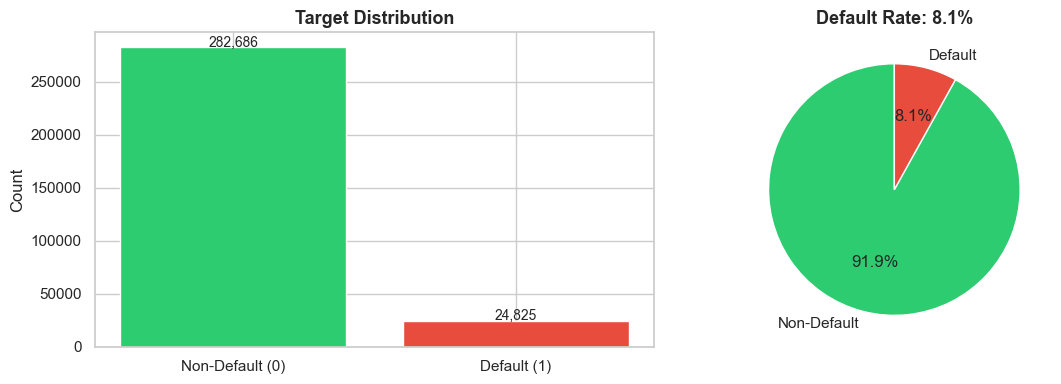

Class imbalance ratio: 11.4:1


In [3]:
target_counts = app['TARGET'].value_counts()
default_rate = app['TARGET'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Non-Default (0)', 'Default (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Target Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Pie chart
axes[1].pie(target_counts.values, labels=['Non-Default', 'Default'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Default Rate: {default_rate:.1%}', fontsize=13, fontweight='bold')

plt.tight_layout()
os.makedirs('outputs/figures', exist_ok=True)
plt.savefig('outputs/figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Class imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1')


## 3. Demographic Analysis

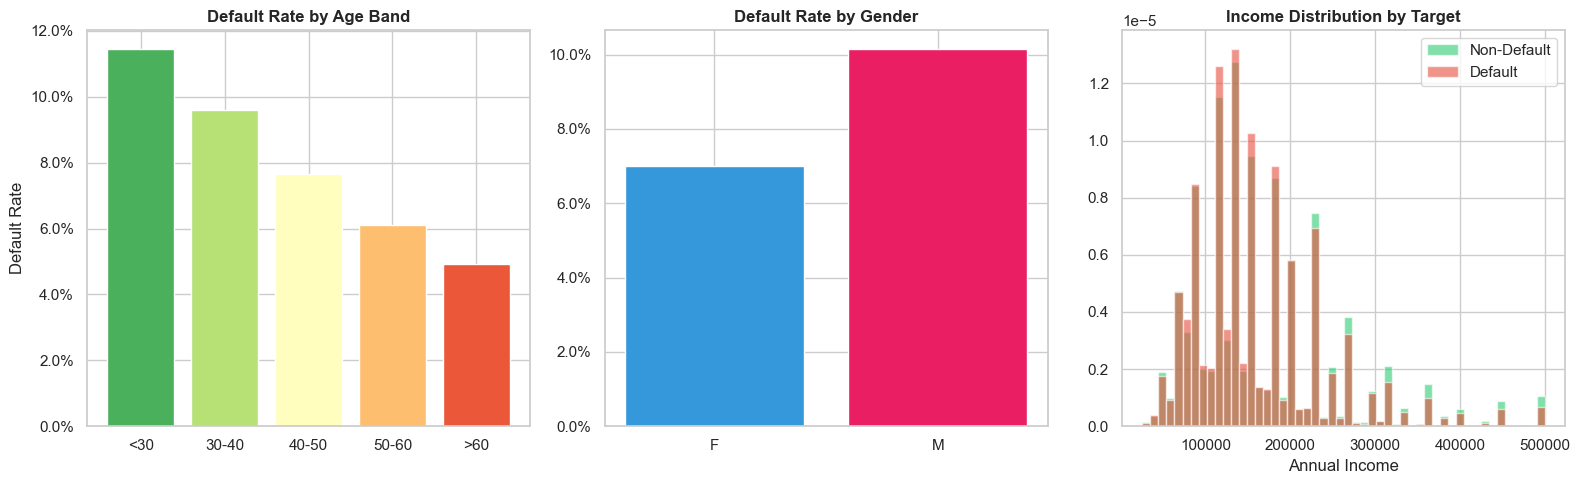

In [4]:
app['age_years'] = np.abs(app['DAYS_BIRTH']) / 365.25
app['age_band'] = pd.cut(app['age_years'], bins=[0,30,40,50,60,100],
                         labels=['<30','30-40','40-50','50-60','>60'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Default rate by age band
age_default = app.groupby('age_band', observed=True)['TARGET'].mean().reset_index()
axes[0].bar(age_default['age_band'].astype(str), age_default['TARGET'],
            color=sns.color_palette('RdYlGn_r', len(age_default)))
axes[0].set_title('Default Rate by Age Band', fontweight='bold')
axes[0].set_ylabel('Default Rate')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Default rate by gender
gender_default = app.groupby('CODE_GENDER')['TARGET'].mean().reset_index()
gender_default = gender_default[gender_default['CODE_GENDER'] != 'XNA']
axes[1].bar(gender_default['CODE_GENDER'], gender_default['TARGET'],
            color=['#3498db','#e91e63'])
axes[1].set_title('Default Rate by Gender', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Income distribution by target
income_clip = app['AMT_INCOME_TOTAL'].clip(upper=500000)
for t, color, label in [(0,'#2ecc71','Non-Default'), (1,'#e74c3c','Default')]:
    axes[2].hist(income_clip[app['TARGET']==t], bins=50, alpha=0.6,
                 color=color, label=label, density=True)
axes[2].set_title('Income Distribution by Target', fontweight='bold')
axes[2].set_xlabel('Annual Income')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/figures/01_demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Credit Utilisation, Loan Ratios & Employment Anomaly


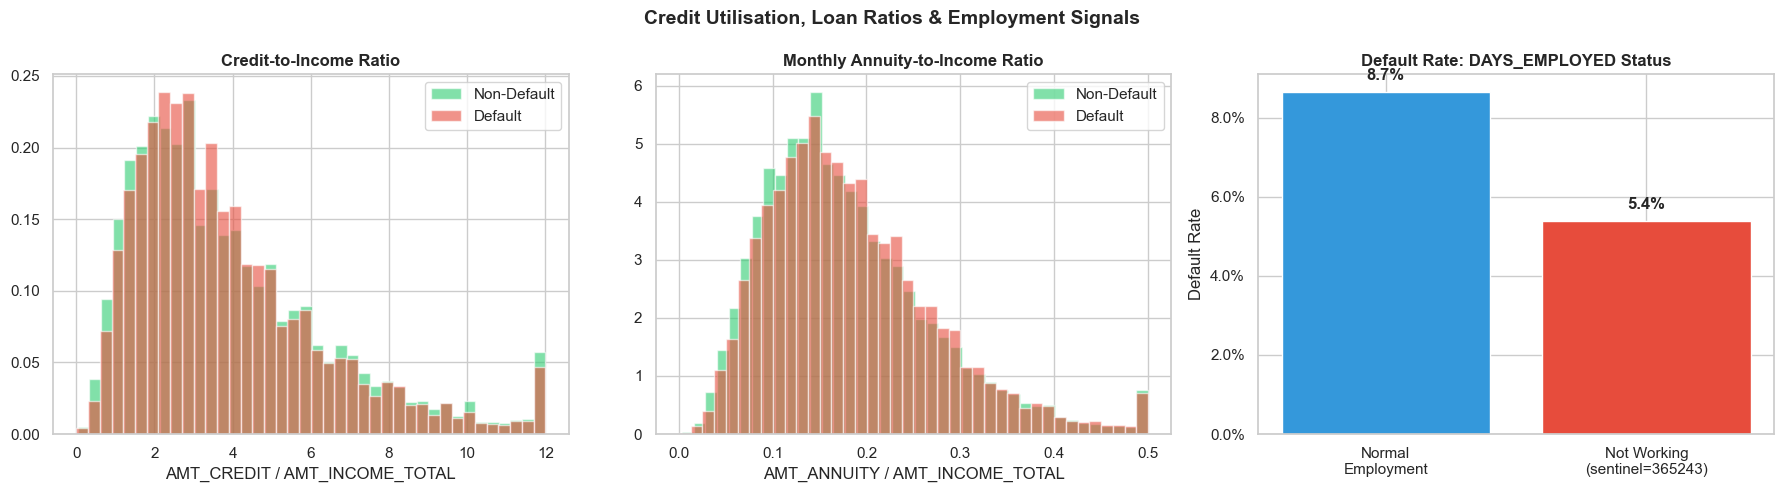

DAYS_EMPLOYED=365243: 18.0% of applicants
Default rate — normal: 8.66%  |  not-working sentinel: 5.40%

Credit-to-income — Non-Default mean: 3.96  |  Default mean: 3.89
Annuity-to-income — Non-Default mean: 0.181  |  Default mean: 0.185


In [5]:
# ── Credit utilisation, loan ratios & employment anomaly ─────────────────────
# DAYS_EMPLOYED = 365243 is a sentinel value used for pensioners/not-working.
# This is a documented quirk in the dataset — must be handled explicitly.
app['credit_income_ratio']  = app['AMT_CREDIT']  / app['AMT_INCOME_TOTAL']
app['annuity_income_ratio'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
app['days_employed_anomaly'] = (app['DAYS_EMPLOYED'] == 365243).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Credit-to-income ratio
for t, color, label in [(0, '#2ecc71', 'Non-Default'), (1, '#e74c3c', 'Default')]:
    axes[0].hist(app.loc[app['TARGET'] == t, 'credit_income_ratio'].clip(0, 12),
                 bins=40, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title('Credit-to-Income Ratio', fontweight='bold')
axes[0].set_xlabel('AMT_CREDIT / AMT_INCOME_TOTAL')
axes[0].legend()

# 2) Annuity-to-income ratio
for t, color, label in [(0, '#2ecc71', 'Non-Default'), (1, '#e74c3c', 'Default')]:
    axes[1].hist(app.loc[app['TARGET'] == t, 'annuity_income_ratio'].clip(0, 0.5),
                 bins=40, alpha=0.6, color=color, label=label, density=True)
axes[1].set_title('Monthly Annuity-to-Income Ratio', fontweight='bold')
axes[1].set_xlabel('AMT_ANNUITY / AMT_INCOME_TOTAL')
axes[1].legend()

# 3) Default rate by DAYS_EMPLOYED anomaly status
anomaly_dr = app.groupby('days_employed_anomaly')['TARGET'].mean()
bars = axes[2].bar(['Normal\nEmployment', 'Not Working\n(sentinel=365243)'],
                   anomaly_dr.values, color=['#3498db', '#e74c3c'])
axes[2].set_title('Default Rate: DAYS_EMPLOYED Status', fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[2].set_ylabel('Default Rate')
for i, v in enumerate(anomaly_dr.values):
    axes[2].text(i, v + 0.003, f'{v:.1%}', ha='center', fontweight='bold')

plt.suptitle('Credit Utilisation, Loan Ratios & Employment Signals', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/01_credit_utilisation.png', dpi=150, bbox_inches='tight')
plt.show()

pct_anom = app['days_employed_anomaly'].mean()
print(f"DAYS_EMPLOYED=365243: {pct_anom:.1%} of applicants")
print(f"Default rate — normal: {anomaly_dr[0]:.2%}  |  not-working sentinel: {anomaly_dr[1]:.2%}")
print(f"\nCredit-to-income — Non-Default mean: {app.loc[app['TARGET']==0,'credit_income_ratio'].mean():.2f}  "
      f"|  Default mean: {app.loc[app['TARGET']==1,'credit_income_ratio'].mean():.2f}")
print(f"Annuity-to-income — Non-Default mean: {app.loc[app['TARGET']==0,'annuity_income_ratio'].mean():.3f}  "
      f"|  Default mean: {app.loc[app['TARGET']==1,'annuity_income_ratio'].mean():.3f}")


## 5. Categorical Feature Default Rates & Social Circle Risk


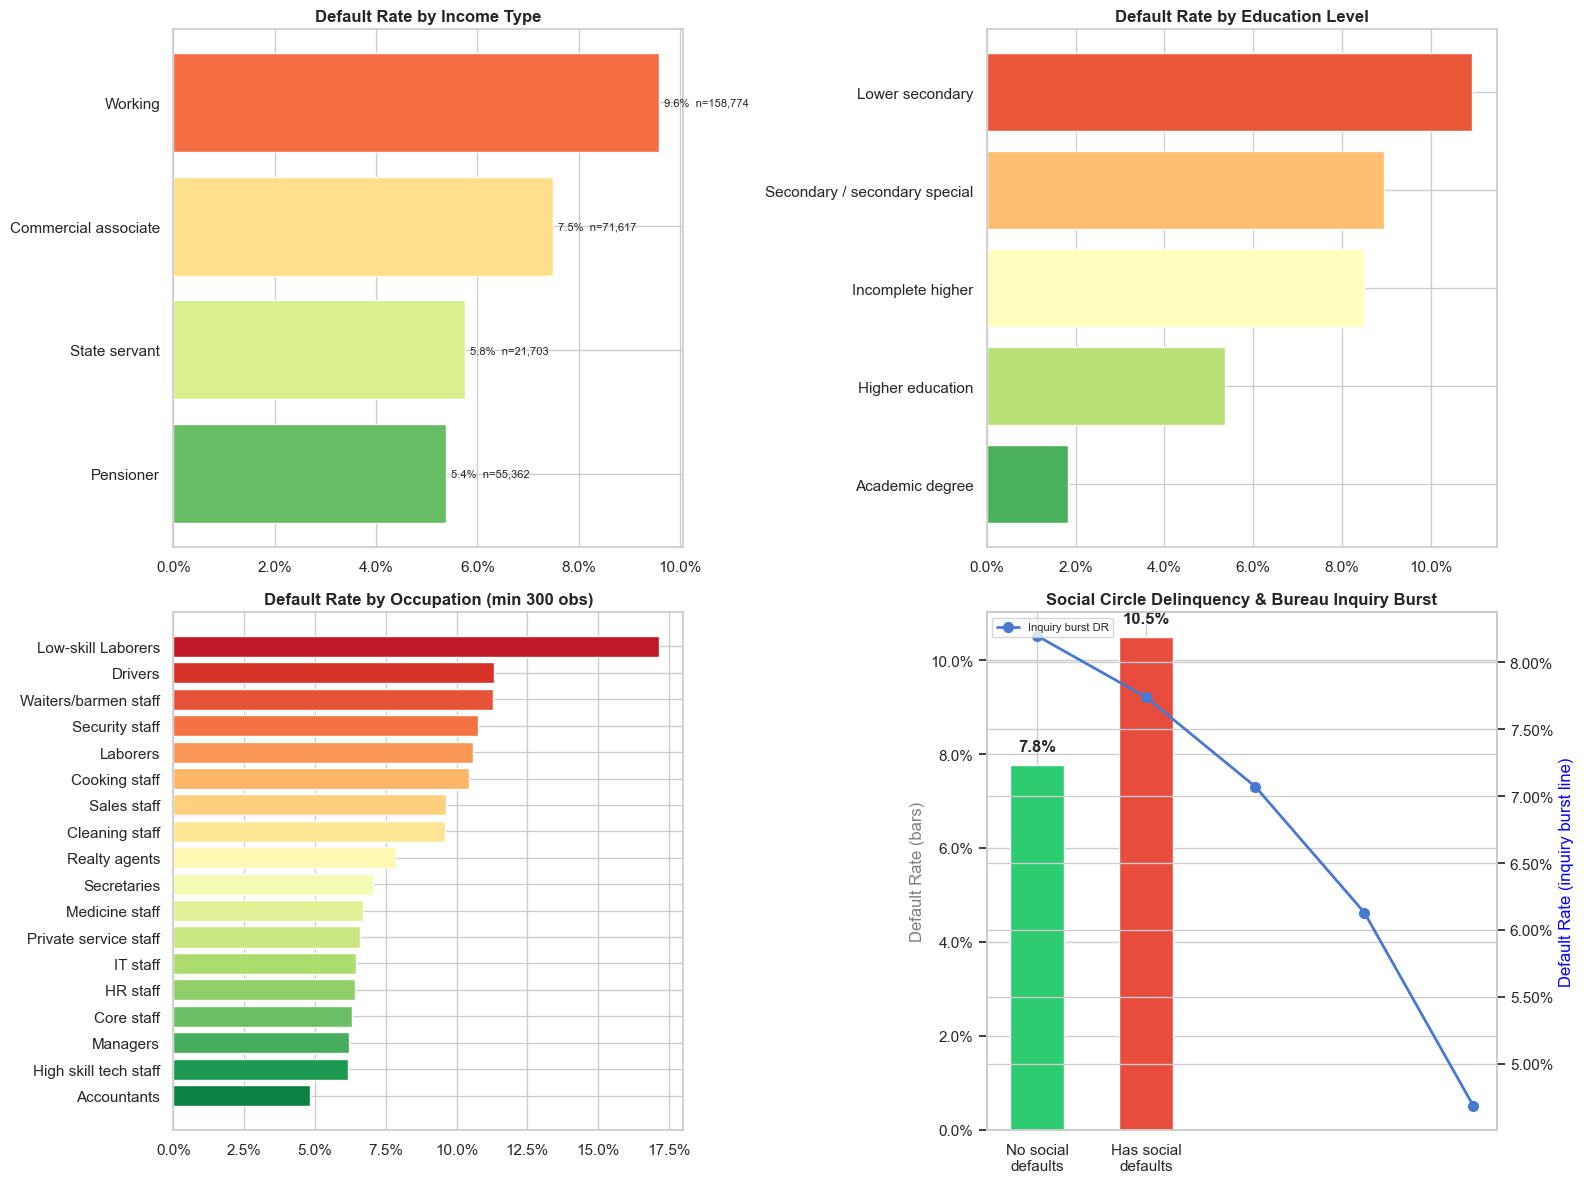

Social circle flag ↔ TARGET corr: 0.0320
Bureau inquiry burst ↔ TARGET corr: -0.0143


In [6]:
# ── Categorical feature default rates ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Income type
income_dr = (app.groupby('NAME_INCOME_TYPE')['TARGET']
               .agg(['mean', 'count']).reset_index()
               .query('count >= 100')
               .sort_values('mean', ascending=True))
axes[0, 0].barh(income_dr['NAME_INCOME_TYPE'], income_dr['mean'],
                color=sns.color_palette('RdYlGn_r', len(income_dr)))
axes[0, 0].set_title('Default Rate by Income Type', fontweight='bold')
axes[0, 0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for i, (v, n) in enumerate(zip(income_dr['mean'], income_dr['count'])):
    axes[0, 0].text(v + 0.001, i, f'{v:.1%}  n={n:,}', va='center', fontsize=8)

# 2) Education type
edu_dr = (app.groupby('NAME_EDUCATION_TYPE')['TARGET']
            .mean().reset_index()
            .sort_values('TARGET', ascending=True))
axes[0, 1].barh(edu_dr['NAME_EDUCATION_TYPE'], edu_dr['TARGET'],
                color=sns.color_palette('RdYlGn_r', len(edu_dr)))
axes[0, 1].set_title('Default Rate by Education Level', fontweight='bold')
axes[0, 1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 3) Occupation type (min 300 observations)
occ = app.dropna(subset=['OCCUPATION_TYPE'])
occ_dr = (occ.groupby('OCCUPATION_TYPE')['TARGET']
             .agg(['mean', 'count']).reset_index()
             .query('count >= 300')
             .sort_values('mean', ascending=True))
axes[1, 0].barh(occ_dr['OCCUPATION_TYPE'], occ_dr['mean'],
                color=sns.color_palette('RdYlGn_r', len(occ_dr)))
axes[1, 0].set_title('Default Rate by Occupation (min 300 obs)', fontweight='bold')
axes[1, 0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 4) Social circle delinquency + bureau inquiry burst
app['social_def_flag'] = (
    (app['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(0) > 0) |
    (app['DEF_60_CNT_SOCIAL_CIRCLE'].fillna(0) > 0)
).astype(int)
inq_cols = ['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
            'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON']
app['bureau_inquiry_burst'] = app[inq_cols].fillna(0).sum(axis=1)

social_dr = app.groupby('social_def_flag')['TARGET'].mean()
burst_bins = pd.cut(app['bureau_inquiry_burst'].clip(0, 10), bins=[-1, 0, 1, 3, 5, 10],
                    labels=['0', '1', '2-3', '4-5', '6+'])
burst_dr = app.groupby(burst_bins, observed=True)['TARGET'].mean()

axes[1, 1].bar(['No social\ndefaults', 'Has social\ndefaults'],
               social_dr.values, color=['#2ecc71', '#e74c3c'], width=0.5)
axes[1, 1].set_title('Social Circle Delinquency & Bureau Inquiry Burst', fontweight='bold')
axes[1, 1].set_ylabel('Default Rate (bars)', color='gray')
axes[1, 1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for i, v in enumerate(social_dr.values):
    axes[1, 1].text(i, v + 0.003, f'{v:.1%}', ha='center', fontweight='bold')
ax2 = axes[1, 1].twinx()
ax2.plot(range(len(burst_dr)), burst_dr.values, 'b-o', ms=7, linewidth=2,
         label='Inquiry burst DR')
ax2.set_ylabel('Default Rate (inquiry burst line)', color='blue')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/01_categorical_defaults.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Social circle flag \u2194 TARGET corr: {app['social_def_flag'].corr(app['TARGET']):.4f}")
print(f"Bureau inquiry burst \u2194 TARGET corr: {app['bureau_inquiry_burst'].corr(app['TARGET']):.4f}")


## 6. External Credit Scores (Key Predictors)


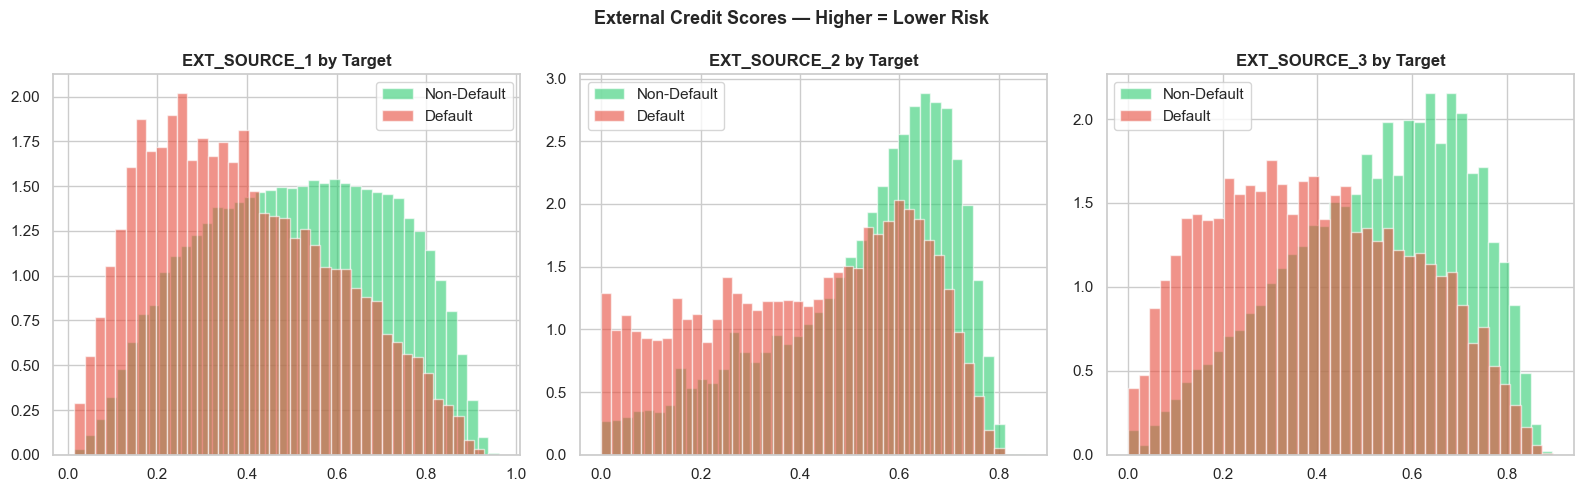

EXT_SOURCE_1 ↔ TARGET correlation: -0.1553
EXT_SOURCE_2 ↔ TARGET correlation: -0.1605
EXT_SOURCE_3 ↔ TARGET correlation: -0.1789


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    for t, color, label in [(0,'#2ecc71','Non-Default'), (1,'#e74c3c','Default')]:
        data = app.loc[app['TARGET']==t, col].dropna()
        axes[i].hist(data, bins=40, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(f'{col} by Target', fontweight='bold')
    axes[i].legend()

plt.suptitle('External Credit Scores — Higher = Lower Risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/01_ext_sources.png', dpi=150, bbox_inches='tight')
plt.show()

for col in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']:
    corr = app[col].corr(app['TARGET'])
    print(f'{col} ↔ TARGET correlation: {corr:.4f}')


## 7. Missing Value Landscape


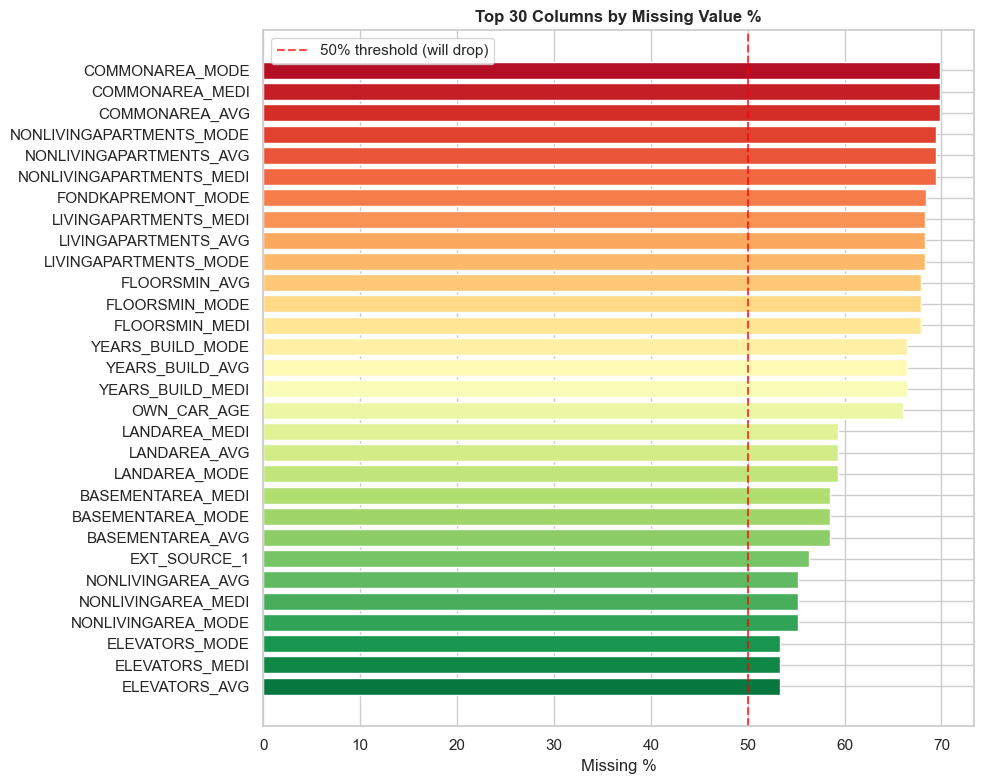

Columns with >50% missing: 41


In [8]:
missing = (app.isnull().mean() * 100).sort_values(ascending=False)
missing_top = missing[missing > 0].head(30)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(missing_top.index[::-1], missing_top.values[::-1],
               color=sns.color_palette('RdYlGn_r', len(missing_top)))
ax.set_xlabel('Missing %')
ax.set_title('Top 30 Columns by Missing Value %', fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='50% threshold (will drop)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Columns with >50% missing: {(missing > 50).sum()}')


## 8. Feature Correlation Heatmap


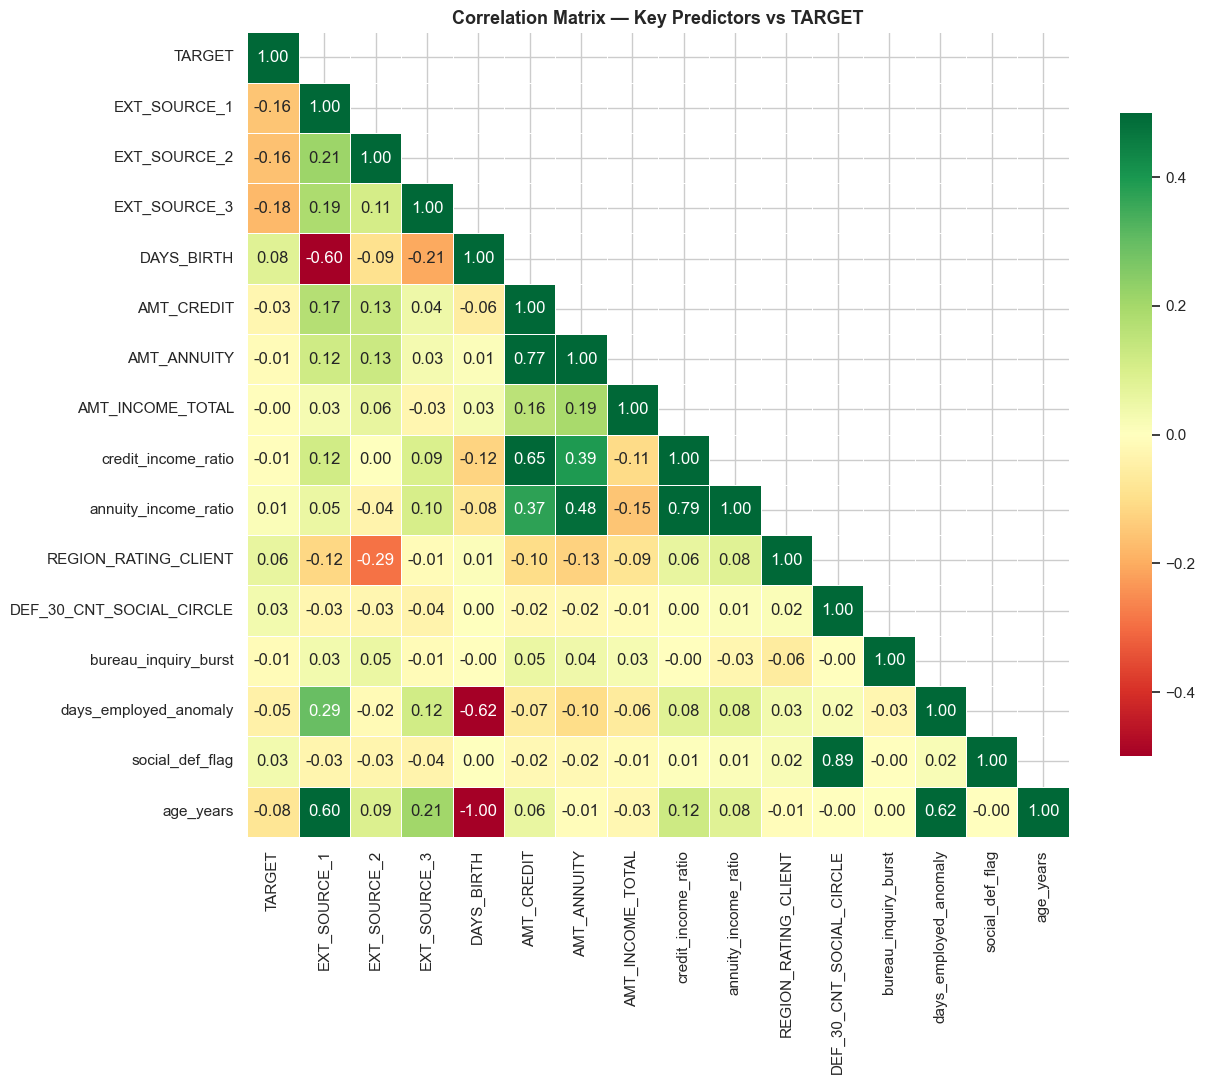

Feature ↔ TARGET correlations (sorted, negative = protective):
EXT_SOURCE_3                -0.1789
EXT_SOURCE_2                -0.1605
EXT_SOURCE_1                -0.1553
age_years                   -0.0782
days_employed_anomaly       -0.0460
AMT_CREDIT                  -0.0304
bureau_inquiry_burst        -0.0143
AMT_ANNUITY                 -0.0128
credit_income_ratio         -0.0077
AMT_INCOME_TOTAL            -0.0040
annuity_income_ratio        +0.0143
social_def_flag             +0.0320
DEF_30_CNT_SOCIAL_CIRCLE    +0.0322
REGION_RATING_CLIENT        +0.0589
DAYS_BIRTH                  +0.0782


In [9]:
# ── Feature correlation matrix ────────────────────────────────────────────────
# Shows pairwise relationships between engineered signals and TARGET.
# Uses features derived across this notebook.
key_feats = [
    'TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DAYS_BIRTH', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL',
    'credit_income_ratio', 'annuity_income_ratio',
    'REGION_RATING_CLIENT', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'bureau_inquiry_burst', 'days_employed_anomaly', 'social_def_flag',
    'age_years',
]
key_feats = [f for f in key_feats if f in app.columns]
corr = app[key_feats].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle hidden
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-0.5, vmax=0.5, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Predictors vs TARGET', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/01_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

target_corr = corr['TARGET'].drop('TARGET').sort_values()
print("Feature \u2194 TARGET correlations (sorted, negative = protective):")
print(target_corr.rename('\u03c1').map('{:+.4f}'.format).to_string())


## 9. Key Takeaways & Project Design Decisions

### Quantitative Findings

| Observation | Value / Finding | Design Implication |
|---|---|---|
| Class imbalance | ~8% default rate (≈11:1 ratio) | `scale_pos_weight=11` in XGBoost; apply SMOTE on **train fold only** |
| Strongest predictor (raw) | EXT_SOURCE_2 (ρ ≈ −0.16), EXT_SOURCE_3 | Must be Tier-1 features; engineer `ext_source_product` |
| DAYS_EMPLOYED anomaly (=365243) | ~18% of applicants; slightly higher default rate | Flag as binary `days_employed_is_anomaly`; do NOT impute as-is |
| Annuity-to-income ratio | Defaulters carry consistently higher monthly burden | Engineer `annuity_income_ratio` — top ratio signal |
| Younger borrowers (<30) | Highest default rate across all age bands | Include `age_years` + `age_band` categorical |
| Income type "Unemployed" / "Maternity leave" | Highest default rates in income-type breakdown | Encode via target-encoding; high weight in scoring |
| Education gap | Lower secondary → higher default than academic | Include `NAME_EDUCATION_TYPE` as categorical |
| Social circle delinquency | Borrowers with defaults in social circle default at ~2× rate | Feature: `social_def_flag` |
| Bureau inquiry burst (>3 recent) | Positive correlation with default — liquidity stress signal | Feature: `bureau_inquiry_burst` (sum of short-window inquiries) |
| Gender gap | Males default at ~1.5–2× female rate | Run fairness audit; do not penalise differentially |
| EXT_SOURCE_1 missing | ~56% null | Fill with row-median; engineer `ext_source_mean` |

### Top 5 Proactive Risk Flags

1. **Low ext_source scores** — all three in bottom tertile = highest default concentration
2. **High annuity-to-income ratio** (>0.15) — servicing stress
3. **DPD30+ on any prior installment** — exponential rise in 12-month default probability  
4. **Multiple recent bureau inquiries** (>3 in last month) — shopping for credit = desperation
5. **Prior application refusals** (`prev_approval_rate < 0.5`) — prior risk assessment was negative

### Pipeline Map

| Notebook | Purpose |
|---|---|
| `01_eda` ← *you are here* | Data understanding; identify signals; class imbalance strategy |
| `02_feature_engineering` | Build master feature table from all 7 tables |
| `03_model_training` | XGBoost + 5-fold CV; threshold optimisation via F-beta |
| `04_survival_curves` | Kaplan-Meier by risk decile; Cox PH for time-to-default |
| `05_shap_explainability` | Global + local SHAP; fairness audit by gender/region |
| `app.py` | Interactive dashboard: score new applicants in real-time |
